# Motor Insurance Claim Frequency Risk Segmentation

### Objective
To compute exposure-adjusted claim frequency and identify key risk drivers
across driver age, vehicle age, and bonus-malus bands.

### Dataset
freMTPL2 Motor Insurance Dataset  
678,013 policies  
36,102 claims  
358,499 exposure years  

### Methodology
Claim Frequency = Total Claims / Total Exposure

In [1]:
import pandas as pd

from pathlib import Path
import pandas as pd

# Automatically detect project root (where requirements.txt exists)
root = Path().resolve()
while not (root / "requirements.txt").exists() and root != root.parent:
    root = root.parent

data_path = root / "data" / "data.csv"

if not data_path.exists():
    raise FileNotFoundError(
        f"\nDataset not found at: {data_path}\n"
        "Please place your dataset file as 'data/data.csv'.\n"
        "The dataset is not included in the repository."
    )

df = pd.read_csv(data_path)

print("Dataset loaded successfully.")

df.shape

Dataset loaded successfully.


(678013, 12)

## Portfolio-Level Claim Frequency

In [27]:
total_claims = df["ClaimNb"].sum()
total_exposure = df["Exposure"].sum()

portfolio_frequency = total_claims / total_exposure

print(f"Total Policies: {df.shape[0]:,}")
print(f"Total Claims: {int(total_claims):,}")
print(f"Total Exposure: {total_exposure:,.2f}")
print(f"Portfolio Claim Frequency: {portfolio_frequency:.2%}")

Total Policies: 678,013
Total Claims: 36,102
Total Exposure: 358,499.45
Portfolio Claim Frequency: 10.07%


## Driver Age Band Analysis

In [28]:
df["Age_Band"] = pd.cut(
    df["DrivAge"],
    bins=[17, 25, 35, 50, 100],
    labels=["18-25", "26-35", "36-50", "50+"]
)

age_summary = df.groupby("Age_Band").agg(
    Total_Claims=("ClaimNb", "sum"),
    Total_Exposure=("Exposure", "sum")
)

age_summary["Frequency"] = age_summary["Total_Claims"] / age_summary["Total_Exposure"]
age_summary_display = age_summary.copy()
age_summary_display["Frequency"] = (age_summary_display["Frequency"] * 100).round(1)
age_summary_display = age_summary_display.rename(columns={"Frequency": "Frequency (%)"})
age_summary_display

,Total_Claims,Total_Exposure,Frequency (%)
Age_Band,,,
18-25,2841,16227.903263,17.5
26-35,6662,69266.778075,9.6
36-50,13118,131989.064957,9.9
50+,13481,141015.699167,9.6


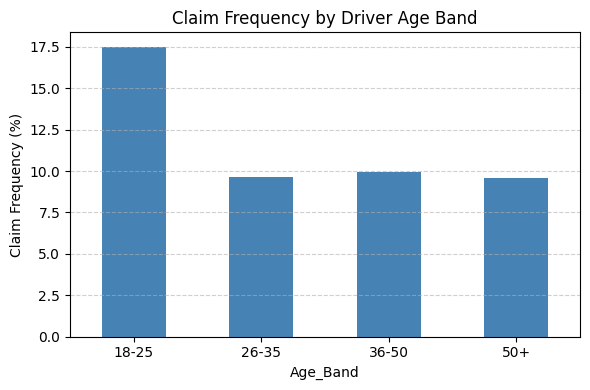

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
(age_summary["Frequency"] * 100).plot(kind="bar", color="steelblue")

plt.title("Claim Frequency by Driver Age Band")
plt.ylabel("Claim Frequency (%)")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

## Vehicle Age Band Analysis

We segment policies based on vehicle age to assess whether newer vehicles 
exhibit different claim frequency patterns compared to older vehicles.

In [30]:
# Create Vehicle Age Bands
df["Vehicle_Age_Band"] = pd.cut(
    df["VehAge"],
    bins=[-1, 2, 5, 100],
    labels=["0-2 years", "3-5 years", "5+ years"]
)

# Aggregate claims and exposure
vehicle_summary = df.groupby("Vehicle_Age_Band").agg(
    Total_Claims=("ClaimNb", "sum"),
    Total_Exposure=("Exposure", "sum")
)

# Compute frequency
vehicle_summary["Frequency"] = (
    vehicle_summary["Total_Claims"] / vehicle_summary["Total_Exposure"]
)
vehicle_summary_display = vehicle_summary.copy()
vehicle_summary_display["Frequency"] = (vehicle_summary_display["Frequency"] * 100).round(1)
vehicle_summary_display = vehicle_summary_display.rename(columns={"Frequency": "Frequency (%)"})
vehicle_summary_display

,Total_Claims,Total_Exposure,Frequency (%)
Vehicle_Age_Band,,,
0-2 years,10904,79176.055347,13.8
3-5 years,6743,72040.123776,9.4
5+ years,18455,207283.266338,8.9


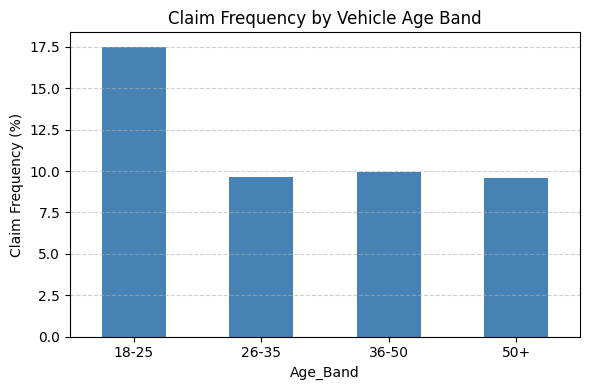

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
(age_summary["Frequency"] * 100).plot(kind="bar", color="steelblue")

plt.title("Claim Frequency by Vehicle Age Band")
plt.ylabel("Claim Frequency (%)")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

**Observation:**  
Newer vehicles (0–2 years) exhibit higher claim frequency relative to older vehicles.

## Bonus-Malus Band Analysis

Bonus-Malus is a proxy for historical risk. 
We group policies into risk bands to examine whether 
claim frequency increases with higher Bonus-Malus scores.

In [32]:
# Create Bonus-Malus Bands
df["BM_Band"] = pd.cut(
    df["BonusMalus"],
    bins=[0, 50, 60, 80, 200],
    labels=["Low (<=50)", "Medium (51-60)", "High (61-80)", "Very High (80+)"]
)

# Aggregate claims and exposure
bm_band_summary = df.groupby("BM_Band").agg(
    Total_Claims=("ClaimNb", "sum"),
    Total_Exposure=("Exposure", "sum")
)

# Compute frequency
bm_band_summary["Frequency"] = (
    bm_band_summary["Total_Claims"] / bm_band_summary["Total_Exposure"]
)
bm_summary_display = bm_band_summary.copy()
bm_summary_display["Frequency"] = (bm_summary_display["Frequency"] * 100).round(1)
bm_summary_display = bm_summary_display.rename(columns={"Frequency": "Frequency (%)"})
bm_summary_display

,Total_Claims,Total_Exposure,Frequency (%)
BM_Band,,,
Low (<=50),18056,225233.130902,8.0
Medium (51-60),4553,47985.497013,9.5
High (61-80),7057,53065.346794,13.3
Very High (80+),6434,32214.680753,20.0


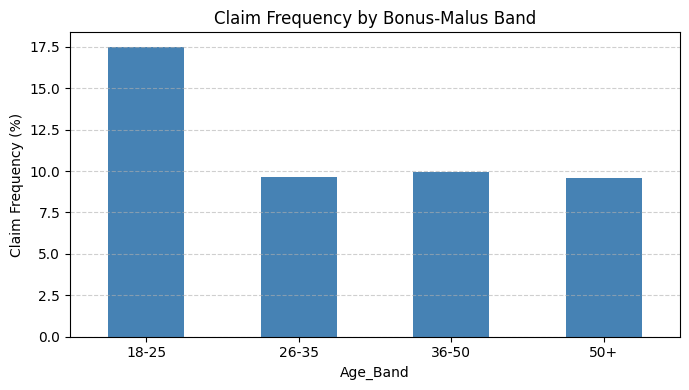

In [33]:
plt.figure(figsize=(7,4))
(age_summary["Frequency"] * 100).plot(kind="bar", color="steelblue")

plt.title("Claim Frequency by Bonus-Malus Band")
plt.ylabel("Claim Frequency (%)")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

**Observation:**  
Claim frequency increases monotonically across Bonus-Malus bands, 
indicating strong risk stratification.